In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler
from sklearn.neighbors import KNeighborsClassifier,KNeighborsRegressor
import seaborn as sns
from sklearn.metrics import f1_score,mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [4]:
df1=pd.read_csv("diamonds KNN.csv")

In [5]:
df1.head(4)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63


In [6]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


<Axes: ylabel='price'>

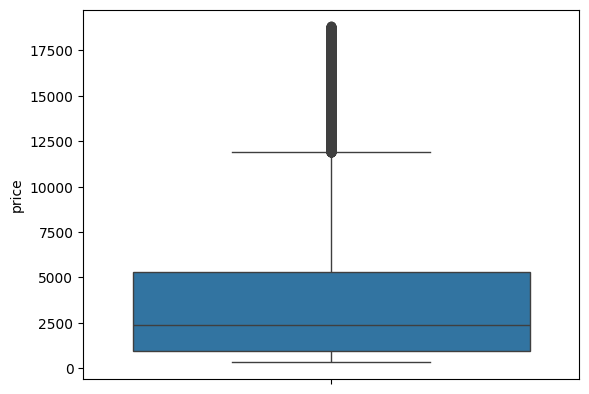

In [7]:
sns.boxplot(df1['price'])

In [8]:
x=df1.drop(['price'],axis=1)
y=df1['price']

In [9]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

In [10]:
num_col=xtrain.select_dtypes(include='number').columns
cat_col=xtrain.select_dtypes(exclude='number').columns

In [11]:
preprocessing=ColumnTransformer([
    ('scaler',StandardScaler(),num_col),
    ('label_encoder',OneHotEncoder(sparse_output=False,handle_unknown='ignore'),cat_col)
]
)

In [12]:
pipeline=Pipeline([
    ('preprocessing',preprocessing),
    ('model',KNeighborsRegressor(metric='manhattan',n_neighbors=5))
])
pipeline.fit(xtrain,ytrain)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scaler', ...), ('label_encoder', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [13]:
pipeline.score(xtrain,ytrain)

0.9860706301949542

In [14]:
pipeline.score(xtest,ytest)

0.9780001091719642

In [15]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid={
        'model__n_neighbors': [3],
        'model__metric': ['manhattan']
    },
    cv=3,
    verbose=1,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
grid_search.fit(xtrain, ytrain)

Fitting 3 folds for each of 1 candidates, totalling 3 fits


,estimator,Pipeline(step...manhattan'))])
,param_grid,"{'model__metric': ['manhattan'], 'model__n_neighbors': [3]}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('scaler', ...), ('label_encoder', ...)]"


In [16]:
grid_search.best_params_

{'model__metric': 'manhattan', 'model__n_neighbors': 3}

In [17]:
model = grid_search.best_estimator_

In [18]:
model.fit(xtrain,ytrain)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scaler', ...), ('label_encoder', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [19]:
model.score(xtrain,ytrain)

0.9894929835786052

In [20]:
model.score(xtest,ytest)

0.9772780183358801

In [21]:
y_pred=model.predict(xtrain)

In [22]:
y_pred1=model.predict(xtest)

In [23]:
mean_squared_error(ytrain,y_pred)

167268.95640732502

In [24]:
mean_squared_error(ytest,y_pred1)

361207.28553330863